# Lozano-Smith Algorithm

In [18]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

EXEC_PATH = '/Applications/CPLEX_Studio221/cplex/bin/x86-64_osx/cplex'

In [19]:
data = pd.read_excel('../Instances/input.xlsx', None)

## Initialization

In [20]:
def INIT(data):
    model = pyo.ConcreteModel() # create model
    
    mult = 100 # <--------------- multiplication factor for making the variable integer

    # data
    t = len(data['dataset']['Time'])
    PI = data['dataset']['Spot Market'].values.flatten() * mult

    X_low = data['average']['MIN'].values.flatten() * mult
    X_up = data['average']['MAX'].values.flatten() * mult
    X_avg = 10

    p = len(data['periods']['PERIOD'])
    Q_begin = data['periods']['BEGIN'].tolist()
    Q_end = data['periods']['END'].tolist()
    Q_len = data['periods']['LEN'].tolist() 

    i = len(data['Trip time']['Time begin (min)'])
    k = len(data['Buses']['Bus (kWh)'])
    n = len(data['Chargers']['Charger (kWh/min)'])
    T_start = data['Trip time']['Time begin (min)'].tolist()
    T_start = [int(x) for x in T_start]
    T_end = data['Trip time']['Time finish (min)'].tolist()
    T_end = [int(x) for x in T_end]
    alpha = data['Chargers']['Charger (kWh/min)'].tolist()
    gama = data['Energy consumption']['Uncertain energy (kWh/km*min)'].tolist()
    ch_eff = 0.90
    E_0 = 0.2
    E_min = 0.2
    E_max = 1
    E_end = 0.2
    C_bat = data['Buses']['Bus (kWh)'].tolist()
    T_final = t

    # sets
    model.P = pyo.RangeSet(p) # set of periods
    model.I = pyo.RangeSet(i) # set of trips
    model.T = pyo.RangeSet(t) # set of timesteps
    model.K = pyo.RangeSet(k) # set of buses
    model.N = pyo.RangeSet(n) # set of chargers

    # parameters
    model.PI = pyo.Param(model.T, initialize=lambda model, t: PI[t-1])  # spot market electricity prices
    model.Q_begin = pyo.Param(model.P, initialize=lambda model, p: Q_begin[p-1]) # Period Q_p starting time
    model.Q_end = pyo.Param(model.P, initialize=lambda model, p: Q_end[p-1]) # Period Q_p ending time
    model.Q_len = pyo.Param(model.P, initialize=lambda model, p: Q_len[p-1]) # Period Q_p length
    model.X_low = pyo.Param(model.P, initialize=lambda model, p: X_low[p-1]) # Mininum value price x can achieve
    model.X_up = pyo.Param(model.P, initialize=lambda model, p: X_up[p-1]) # Maxinum value price x can achieve
    model.X_avg = pyo.Param(initialize=(X_avg)) # Average price x can achieve

    model.T_start = pyo.Param(model.I, initialize=lambda model, i: T_start[i-1]) # start time of trip i
    model.T_end = pyo.Param(model.I, initialize=lambda model, i: T_end[i-1]) # end time of trip i
    model.alpha = pyo.Param(model.N, initialize=lambda model, n: alpha[n-1]) # charging power of charger n
    model.ch_eff = pyo.Param(initialize=ch_eff) # charging efficiency of charger n
    model.gama = pyo.Param(model.I, initialize=lambda model, i: gama[i-1],mutable=True) # energy consumption
    model.E_0 = pyo.Param(initialize=E_0) # initial energy level of bus k
    model.E_min = pyo.Param(initialize=E_min) # minimum energy level allowed for bus k
    model.E_max = pyo.Param(initialize=E_max) # maximum energy level allowed for bus k
    model.E_end = pyo.Param(initialize=E_end) # minimum energy after an operation day for bus k
    model.C_bat = pyo.Param(model.K, initialize=lambda model, k: C_bat[k-1]) # total capacity of the bus k battery

    # non-negative variables
    model.e = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals) # energy level of bus k at time t
    model.w_buy = pyo.Var(model.T, within=pyo.NonNegativeReals) # electricity purchased from the grid at time t
    model.x = pyo.Var(model.P, domain=pyo.NonNegativeIntegers) # electricity price x at period p

    # binary variables
    model.b = pyo.Var(model.K,model.I, model.T, within=pyo.Binary) # binary variable indicating if bus k is serving trip i at time t
    model.y = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary) # binary variable indicating if bus k is charging
    model.c = pyo.Var(model.K, model.T, domain=pyo.Binary)  # binary variable indicating if bus k is parked to charge at time t

    # constraints
    model.constraints = pyo.ConstraintList()
    
    ### UL ###
    # constraint 2
    for p in model.P:
        model.constraints.add(model.x[p] >= model.X_low[p])
    
    for p in model.P:
        model.constraints.add(model.x[p] <= model.X_up[p])

    # constraint 3
    model.constraints.add(((1/T_final) * sum(model.Q_len[p] * model.x[p] for p in model.P)) <= model.X_avg)

    ### LL ###
    #constraint 5
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.b[k,i,t] for i in model.I) + model.c[k,t] <=1)

    #constraint 6
    for i in model.I: 
        for t in range(model.T_start[i],model.T_end[i]):
            model.constraints.add(sum(model.b[k,i,t] for k in model.K) == 1)

    #constraint 7
    for i in model.I:
        for k in model.K:
            for t in range(model.T_start[i],model.T_end[i]-1):
                model.constraints.add(model.b[k,i,t+1] >= model.b[k,i,t])

    #constraint 8
    for n in model.N:
        for t in model.T:
            model.constraints.add(sum(model.y[k,n,t] for k in model.K) <= 1)

    #constraint 9
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.y[k,n,t] for n in model.N) <= model.c[k,t])

    #constraint 10
    for k in model.K:
        for t in range(2,T_final+1):
            model.constraints.add(model.e[k,t] == model.e[k,t-1] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N) - sum(model.gama[i]*model.b[k,i,t] for i in model.I))
    
    #constraint 11
    for t in model.T:
        model.constraints.add(sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N for k in model.K) == model.w_buy[t])

    #constraint 14
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.e[k,t] >= model.C_bat[k] * model.E_min)

    #constrait 15
    for k in model.K:
        for t in model.T:
            model.constraints.add(E_max * model.C_bat[k] >= model.e[k,t] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N))          

    #constraint 16
    for k in model.K:
        model.constraints.add(model.e[k,1] == model.E_0*model.C_bat[k])

    #constraint 17
    for k in model.K:
        model.constraints.add(model.e[k,T_final-1] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N) >= model.E_end*model.C_bat[k])

    # extras
    for k in model.K:
        model.constraints.add(sum(model.ch_eff*model.alpha[n]*model.y[k,n,1] for n in model.N)==0)

    # objective function
    def rule_obj(mod):
        return sum(mod.x[p] * mod.w_buy[t] for p in mod.P for t in range(mod.Q_begin[p],mod.Q_end[p])) - sum(mod.PI[t] * mod.w_buy[t] for t in model.T)
    model.obj = pyo.Objective(rule=rule_obj, sense=pyo.maximize)

    try:
        opt = pyo.SolverFactory('gurobi')
        opt.options['timelimit'] = 3600
        opt.options['mipgap'] = 0.01
        results = opt.solve(model,tee=False)
    except:
        try:
            SolverFactory('mindtpy').solve(model, mip_solver='gurobi', nlp_solver='ipopt', tee=False)        
        except Exception:
            pass
            print('\n##############----------- Ignored Exception -----------##############')
    return model

## HPR

In [21]:
def solveHRP(data,y_l):
    model = pyo.ConcreteModel() # create model
    
    mult = 100 # <--------------- multiplication factor for making the variable integer

    # data
    t = len(data['dataset']['Time'])
    PI = data['dataset']['Spot Market'].values.flatten() * mult

    X_low = data['average']['MIN'].values.flatten() * mult
    X_up = data['average']['MAX'].values.flatten() * mult
    X_avg = 5

    p = len(data['periods']['PERIOD'])
    Q_begin = data['periods']['BEGIN'].tolist()
    Q_end = data['periods']['END'].tolist()
    Q_len = data['periods']['LEN'].tolist() 

    i = len(data['Trip time']['Time begin (min)'])
    k = len(data['Buses']['Bus (kWh)'])
    n = len(data['Chargers']['Charger (kWh/min)'])
    T_start = data['Trip time']['Time begin (min)'].tolist()
    T_start = [int(x) for x in T_start]
    T_end = data['Trip time']['Time finish (min)'].tolist()
    T_end = [int(x) for x in T_end]
    alpha = data['Chargers']['Charger (kWh/min)'].tolist()
    gama = data['Energy consumption']['Uncertain energy (kWh/km*min)'].tolist()
    ch_eff = 0.90
    E_0 = 0.2
    E_min = 0.2
    E_max = 1
    E_end = 0.2
    C_bat = data['Buses']['Bus (kWh)'].tolist()
    T_final = t

    # sets
    model.P = pyo.RangeSet(p) # set of periods
    model.I = pyo.RangeSet(i) # set of trips
    model.T = pyo.RangeSet(t) # set of timesteps
    model.K = pyo.RangeSet(k) # set of buses
    model.N = pyo.RangeSet(n) # set of chargers

    # parameters
    model.PI = pyo.Param(model.T, initialize=lambda model, t: PI[t-1])  # spot market electricity prices
    model.Q_begin = pyo.Param(model.P, initialize=lambda model, p: Q_begin[p-1]) # Period Q_p starting time
    model.Q_end = pyo.Param(model.P, initialize=lambda model, p: Q_end[p-1]) # Period Q_p ending time
    model.Q_len = pyo.Param(model.P, initialize=lambda model, p: Q_len[p-1]) # Period Q_p length
    model.X_low = pyo.Param(model.P, initialize=lambda model, p: X_low[p-1]) # Mininum value price x can achieve
    model.X_up = pyo.Param(model.P, initialize=lambda model, p: X_up[p-1]) # Maxinum value price x can achieve
    model.X_avg = pyo.Param(initialize=(X_avg)) # Average price x can achieve

    model.T_start = pyo.Param(model.I, initialize=lambda model, i: T_start[i-1]) # start time of trip i
    model.T_end = pyo.Param(model.I, initialize=lambda model, i: T_end[i-1]) # end time of trip i
    model.alpha = pyo.Param(model.N, initialize=lambda model, n: alpha[n-1]) # charging power of charger n
    model.ch_eff = pyo.Param(initialize=ch_eff) # charging efficiency of charger n
    model.gama = pyo.Param(model.I, initialize=lambda model, i: gama[i-1],mutable=True) # energy consumption
    model.E_0 = pyo.Param(initialize=E_0) # initial energy level of bus k
    model.E_min = pyo.Param(initialize=E_min) # minimum energy level allowed for bus k
    model.E_max = pyo.Param(initialize=E_max) # maximum energy level allowed for bus k
    model.E_end = pyo.Param(initialize=E_end) # minimum energy after an operation day for bus k
    model.C_bat = pyo.Param(model.K, initialize=lambda model, k: C_bat[k-1]) # total capacity of the bus k battery

    model.y_l = pyo.Param(model.T, initialize=y_l)

    # non-negative variables
    model.e = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals) # energy level of bus k at time t
    model.w_buy = pyo.Var(model.T, within=pyo.NonNegativeReals) # electricity purchased from the grid at time t
    model.x = pyo.Var(model.P, domain=pyo.NonNegativeIntegers) # electricity price x at period p

    # binary variables
    model.b = pyo.Var(model.K,model.I, model.T, within=pyo.Binary) # binary variable indicating if bus k is serving trip i at time t
    model.y = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary) # binary variable indicating if bus k is charging
    model.c = pyo.Var(model.K, model.T, domain=pyo.Binary)  # binary variable indicating if bus k is parked to charge at time t

    # constraints
    model.constraints = pyo.ConstraintList()
    
    ### UL ###
    # constraint 2
    for p in model.P:
        model.constraints.add(model.x[p] >= model.X_low[p])
    
    for p in model.P:
        model.constraints.add(model.x[p] <= model.X_up[p])

    # constraint 3
    model.constraints.add(((1/T_final) * sum(model.Q_len[p] * model.x[p] for p in model.P)) <= model.X_avg)


    ### LL ###        
    
    #constraint 5
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.b[k,i,t] for i in model.I) + model.c[k,t] <=1)

    #constraint 6
    for i in model.I: 
        for t in range(model.T_start[i],model.T_end[i]):
            model.constraints.add(sum(model.b[k,i,t] for k in model.K) == 1)

    #constraint 7
    for i in model.I:
        for k in model.K:
            for t in range(model.T_start[i],model.T_end[i]-1):
                model.constraints.add(model.b[k,i,t+1] >= model.b[k,i,t])

    #constraint 8
    for n in model.N:
        for t in model.T:
            model.constraints.add(sum(model.y[k,n,t] for k in model.K) <= 1)

    #constraint 9
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.y[k,n,t] for n in model.N) <= model.c[k,t])

    #constraint 10
    for k in model.K:
        for t in range(2,T_final+1):
            model.constraints.add(model.e[k,t] == model.e[k,t-1] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N) - sum(model.gama[i]*model.b[k,i,t] for i in model.I))
    
    #constraint 11
    for t in model.T:
        model.constraints.add(sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N for k in model.K) == model.w_buy[t])

    #constraint 14
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.e[k,t] >= model.C_bat[k] * model.E_min)

    #constrait 15
    for k in model.K:
        for t in model.T:
            model.constraints.add(E_max * model.C_bat[k] >= model.e[k,t] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N))          

    #constraint 16
    for k in model.K:
        model.constraints.add(model.e[k,1] == model.E_0*model.C_bat[k])

    #constraint 17
    for k in model.K:
        model.constraints.add(model.e[k,T_final-1] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N) >= model.E_end*model.C_bat[k])

    #constraint 18
    model.constraints.add(sum(model.x[p] * model.w_buy[t] for p in model.P for t in range(model.Q_begin[p],model.Q_end[p])) <= sum(model.x[p] * model.y_l[t] for p in model.P for t in range(model.Q_begin[p],model.Q_end[p])))

    # objective function
    def rule_obj(mod):
        return sum(mod.x[p] * mod.w_buy[t] for p in mod.P for t in range(mod.Q_begin[p],mod.Q_end[p])) - sum(mod.PI[t] * mod.w_buy[t] for t in model.T)
    model.obj = pyo.Objective(rule=rule_obj, sense=pyo.maximize)

    try:
        SolverFactory('mindtpy').solve(model, mip_solver='gurobi', nlp_solver='ipopt', tee=False) 
    except Exception:
        pass
        print('\n##############----------- Ignored Exception -----------##############')
    return model

## LL

In [22]:

def solveLL(data,x):
    model = pyo.ConcreteModel() # create model
    
    # data
    i = len(data['Trip time']['Time begin (min)'])
    k = len(data['Buses']['Bus (kWh)'])
    n = len(data['Chargers']['Charger (kWh/min)'])
    t = 96
    p = 7

    T_start = data['Trip time']['Time begin (min)'].tolist()
    T_start = [int(x) for x in T_start]
    T_end = data['Trip time']['Time finish (min)'].tolist()
    T_end = [int(x) for x in T_end]
    Q_end = data['periods']['END'].tolist()
    Q_begin = data['periods']['BEGIN'].tolist()
    
    ######
    PI = data['dataset']['Spot Market'].values.flatten() * 100
    ######

    alpha = data['Chargers']['Charger (kWh/min)'].tolist()
    gama = data['Energy consumption']['Uncertain energy (kWh/km*min)'].tolist()
    ch_eff = 0.90

    E_0 = 0.2
    E_min = 0.2
    E_max = 1
    E_end = 0.2
    C_bat = data['Buses']['Bus (kWh)'].tolist()

    T_final = t
    
    # sets
    model.I = pyo.RangeSet(i) # set of trips
    model.T = pyo.RangeSet(t) # set of timesteps
    model.K = pyo.RangeSet(k) # set of buses
    model.N = pyo.RangeSet(n) # set of chargers
    model.P = pyo.RangeSet(p) # number of price periods

    # parameters
    model.T_start = pyo.Param(model.I, initialize=lambda model, i: T_start[i-1]) # start time of trip i
    model.T_end = pyo.Param(model.I, initialize=lambda model, i: T_end[i-1]) # end time of trip i
    model.Q_begin = pyo.Param(model.P, initialize=lambda model, p: Q_begin[p-1])
    model.Q_end = pyo.Param(model.P, initialize=lambda model, p: Q_end[p-1])
    model.alpha = pyo.Param(model.N, initialize=lambda model, n: alpha[n-1]) # charging power of charger n
    model.ch_eff = pyo.Param(initialize=ch_eff) # charging efficiency of charger n
    
    ######
    model.PI = pyo.Param(model.T, initialize=lambda model, t: PI[t-1])  # spot market electricity prices
    ######

    #model.x = pyo.Param(model.P, initialize=lambda model, p: x[p-1]) # electricity purchasing price in time t
    model.x = pyo.Param(model.P, initialize=x) # electricity purchasing price in time t

    model.gama = pyo.Param(model.I, initialize=lambda model, i: gama[i-1]) # energy consumption
    model.E_0 = pyo.Param(initialize=E_0) # initial energy level of bus k
    model.E_min = pyo.Param(initialize=E_min) # minimum energy level allowed for bus k
    model.E_max = pyo.Param(initialize=E_max) # maximum energy level allowed for bus k
    model.E_end = pyo.Param(initialize=E_end) # minimum energy after an operation day for bus k
    model.C_bat = pyo.Param(model.K, initialize=lambda model, k: C_bat[k-1]) # total capacity of the bus k battery
    

    # binary variables
    model.b = pyo.Var(model.K,model.I, model.T, within=pyo.Binary) # binary variable indicating if bus k is serving trip i at time t
    model.y = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary) # binary variable indicating if bus k is occupying a charger n at time t to discharge
    model.c = pyo.Var(model.K, model.T, domain=pyo.Binary)  # binary variable indicating if bus k is charging/discharging at time t

    # non-negative variables
    model.e = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals) # energy level of bus k at time t
    model.w_buy = pyo.Var(model.T, within=pyo.NonNegativeReals) # electricity purchased from the grid at time t


    # constraints
    model.constraints = pyo.ConstraintList()
    
    #constraint 5
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.b[k,i,t] for i in model.I) + model.c[k,t] <=1)

    #constraint 6
    for i in model.I: 
        for t in range(model.T_start[i],model.T_end[i]):
            model.constraints.add(sum(model.b[k,i,t] for k in model.K) == 1)

    #constraint 7
    for i in model.I:
        for k in model.K:
            for t in range(model.T_start[i],model.T_end[i]-1):
                model.constraints.add(model.b[k,i,t+1] >= model.b[k,i,t])

    #constraint 8
    for n in model.N:
        for t in model.T:
            model.constraints.add(sum(model.y[k,n,t] for k in model.K) <= 1)

    #constraint 9
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.y[k,n,t] for n in model.N) <= model.c[k,t])

    #constraint 10
    for k in model.K:
        for t in range(2,T_final+1):
            model.constraints.add(model.e[k,t] == model.e[k,t-1] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N) - sum(model.gama[i]*model.b[k,i,t] for i in model.I))
    
    #constraint 11
    for t in model.T:
        model.constraints.add(sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N for k in model.K) == model.w_buy[t])

    #constraint 14
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.e[k,t] >= model.C_bat[k] * model.E_min)

    #constrait 15
    for k in model.K:
        for t in model.T:
            model.constraints.add(E_max * model.C_bat[k] >= model.e[k,t] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N))          

    #constraint 16
    for k in model.K:
        model.constraints.add(model.e[k,1] == model.E_0*model.C_bat[k])

    #constraint 17
    for k in model.K:
        model.constraints.add(model.e[k,T_final-1] + sum(model.ch_eff*model.alpha[n]*model.y[k,n,t] for n in model.N) >= model.E_end*model.C_bat[k]) 

    # objective function
    def rule_obj(mod):
        return sum(mod.x[p] * mod.w_buy[t] for p in mod.P for t in range(model.Q_begin[p],model.Q_end[p]))
    model.obj = pyo.Objective(rule=rule_obj, sense=pyo.minimize)

    try:
        opt = pyo.SolverFactory('gurobi')
        opt.options['timelimit'] = 3600
        opt.options['mipgap'] = 0.01
        results = opt.solve(model,tee=False)
    except Exception:
        pass
        print('\n##############----------- Ignored Exception -----------##############') 
    return model

## SOLVING

In [23]:
LB = float('-inf')
model_INIT = INIT(data)
UB = pyo.value(model_INIT.obj())
k = 0
x_k = model_INIT.x
y_u = model_INIT.w_buy
epsilon = 0.0001

In [24]:
while(UB != LB):
    print('Starting iteration: ',k)
    
    if k != 0:
        pass
        model_HRP = solveHRP(data,y_l)
        x_k = model_HRP.x
        y_u = model_HRP.w_buy
        UB = model_HRP.obj()
    
    model_LL = solveLL(data,x_k)
    y_l = model_LL.w_buy
    f_y_u = sum(x_k[p] * y_u[t] for p in model_LL.P for t in range(model_LL.Q_begin[p],model_LL.Q_end[p]))

    if pyo.value(f_y_u) - model_LL.obj() <= epsilon:
        LB = UB
    else:
        F_y_l = sum(x_k[p] * y_l[t] for p in model_LL.P for t in range(model_LL.Q_begin[p],model_LL.Q_end[p])) - sum(model_LL.PI[t] * y_l[t] for t in model_LL.T)
        if pyo.value(F_y_l) > LB:
            LB = pyo.value(F_y_l)
    print('Upper bound:',UB,'\nLower Bound',LB,'\n')
    k = k+1

Starting iteration:  0
Upper bound: 3510.0 
Lower Bound 630.0 

Starting iteration:  1
Upper bound: 1102.4999999999998 
Lower Bound 1102.4999999999998 



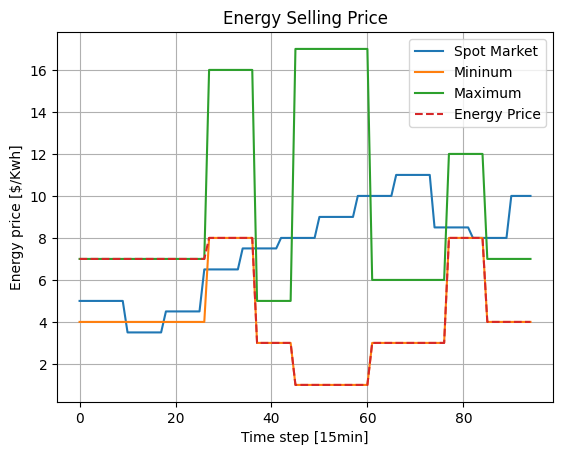

In [25]:
x_data = []
spot_data = []
min_data = []
max_data = []

for p in model_HRP.P:
    for t in range(model_HRP.Q_begin[p], model_HRP.Q_end[p]):    
        x_data.append(pyo.value(x_k[p]))
        spot_data.append(pyo.value(model_HRP.PI[t]))
        min_data.append(pyo.value(model_HRP.X_low[p]))
        max_data.append(pyo.value(model_HRP.X_up[p]))

df = pd.DataFrame({'x': x_data, 'spot': spot_data, 'min': min_data, 'max': max_data})

# Plot the data
plt.plot(df.index, df['spot'], label='Spot Market')
plt.plot(df.index, df['min'], label='Mininum')
plt.plot(df.index, df['max'], label='Maximum')
plt.plot(df.index, df['x'], label='Energy Price', linestyle='--')
plt.xlabel('Time step [15min]')
plt.ylabel('Energy price [$/Kwh]')
plt.title('Energy Selling Price')
plt.grid(True)
plt.legend()
plt.show()

Text(0, 0.5, 'Power [kWh]')

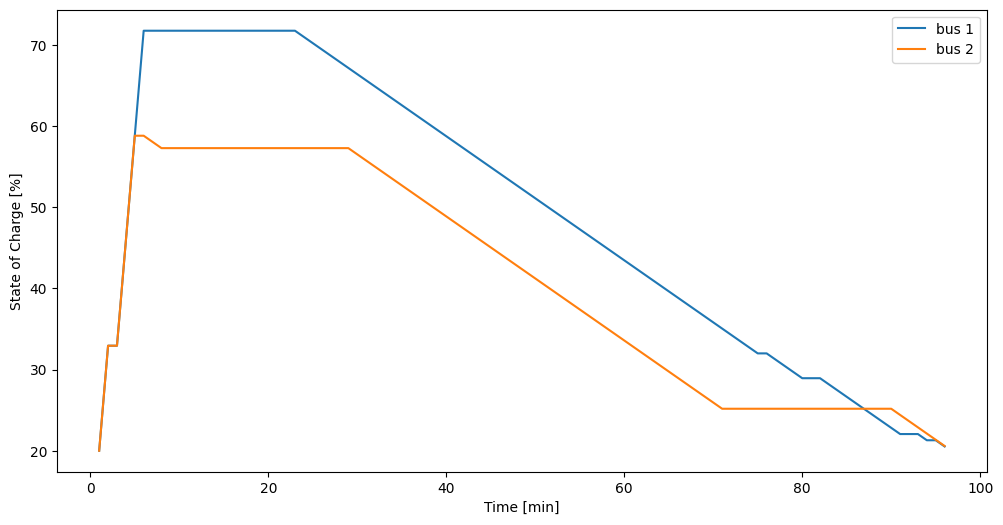

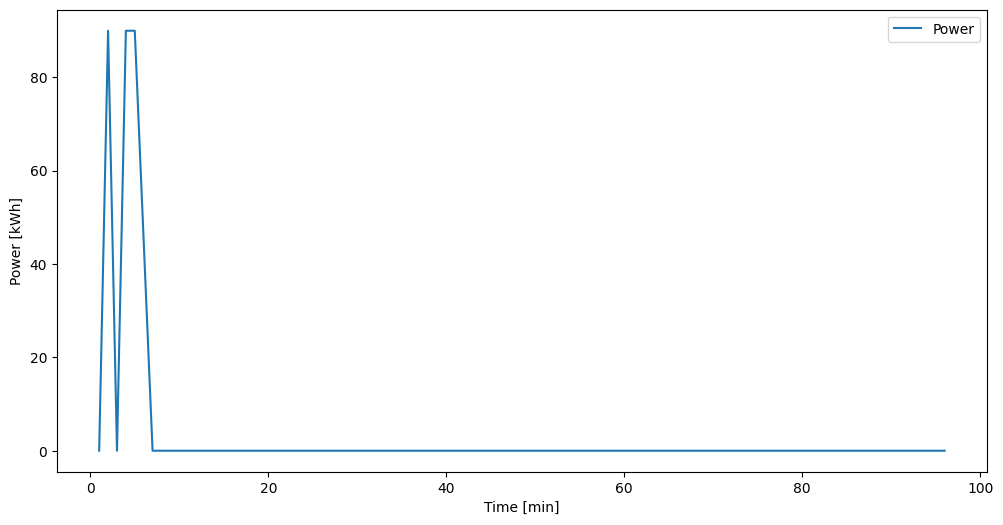

In [26]:
def energy_bus(K,T,e):
    bus_list = []
    energy_list = []
    for k in K:
        bus_number = 'bus' + ' ' + str(k)
        bus_list.append(bus_number)
    for t in T:
        for  k in K:
            energy_list.append(pyo.value(e[k,t]))
    energy_array = np.reshape(energy_list, (len(T), len(bus_list)))
    Energy = pd.DataFrame(energy_array,index=T, columns=bus_list)
    return Energy

def power(T,w):
    transac_list = []
    for t in T:
        value = pyo.value(w[t])
        transac_list.append(value)
    W = pd.DataFrame(transac_list, index=model_LL.T, columns=['Power'])
    return W


C_bat = data['Buses']['Bus (kWh)'].tolist()
Energy = energy_bus(model_LL.K, model_LL.T, model_LL.e)
Energy_perc = (Energy*100)/C_bat[0]
Energy_perc.plot(figsize=(12, 6))
plt.xlabel('Time [min]')
plt.ylabel('State of Charge [%]')

W_buy = power(model_LL.T, y_l)
W_buy.plot(figsize=(12, 6))
plt.xlabel('Time [min]')
plt.ylabel('Power [kWh]')
